# Exploring MDI and MDA with Diabetes Dataset
This notebook lets you explore the Mean Decrease in Impurity (MDI) using the diabetes dataset
from Efron et al. (2004), *Least Angle Regression*. You will visualize both the decision tree
and its computed MDI importances to better understand how splits reduce impurity.

In [53]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import load_diabetes
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Load diabetes dataset and wrap in DataFrame
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

In [54]:
# Train a shallow decision tree for explainability
tree = DecisionTreeRegressor(max_depth=3, random_state=0)
tree.fit(X, y)


tree_ = tree.tree_

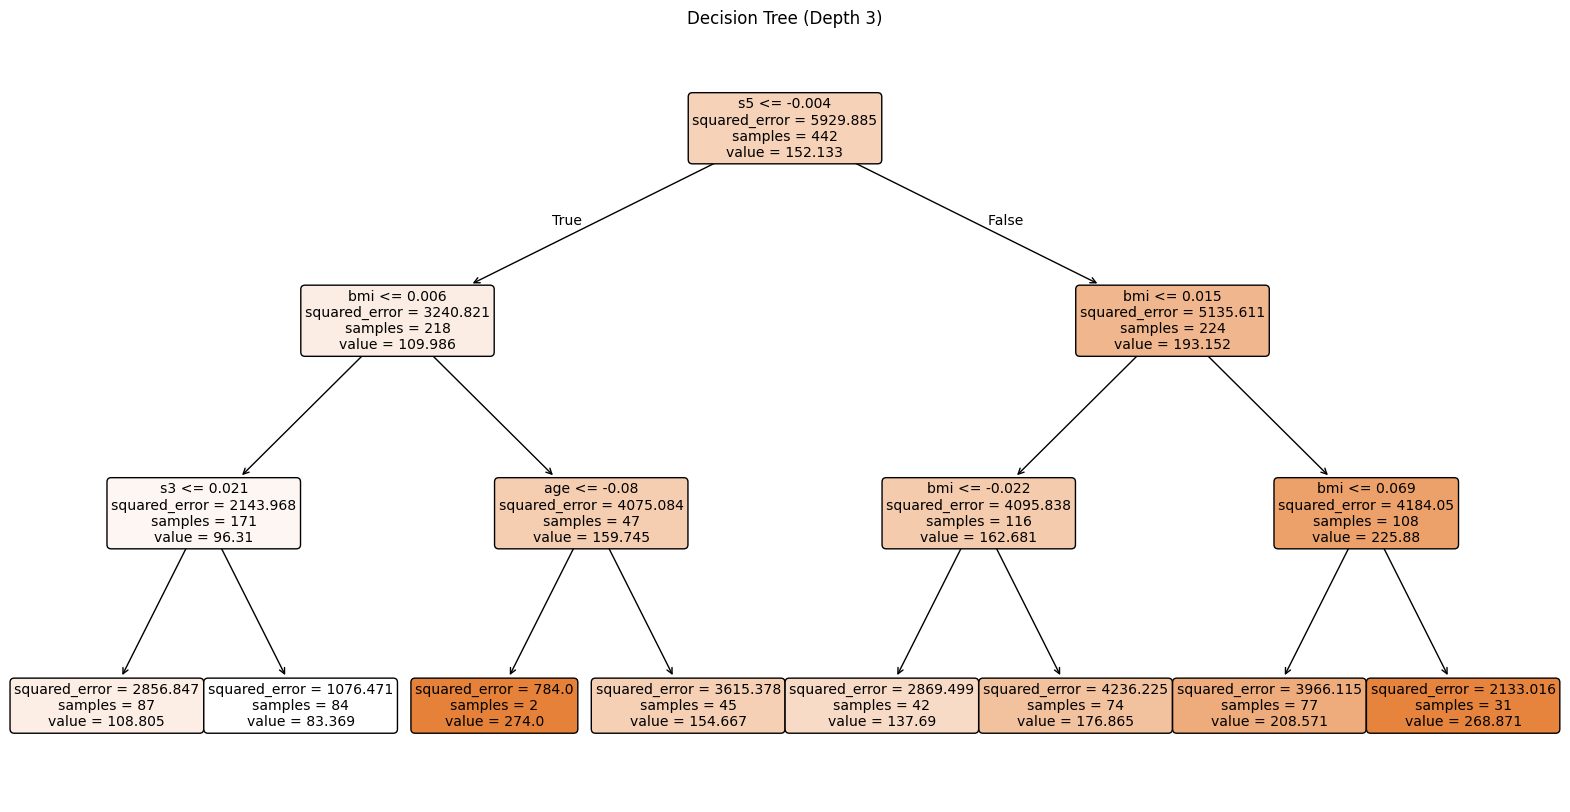

In [55]:
# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X.columns, filled=True, rounded=True)
plt.title('Decision Tree (Depth 3)')
plt.show()

## MDI

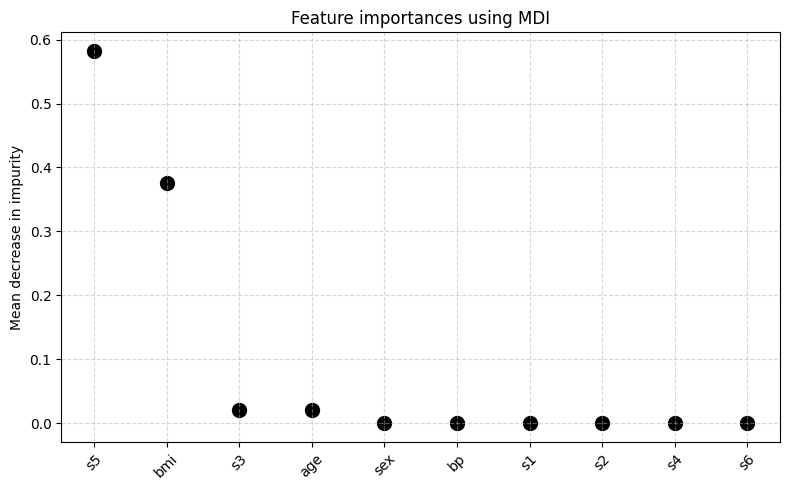

,Feature,MDI
8,s5,0.582301
2,bmi,0.375849
6,s3,0.021070
0,age,0.020780
1,sex,0.000000
3,bp,0.000000
4,s1,0.000000
5,s2,0.000000
7,s4,0.000000
9,s6,0.000000


In [56]:
# Compute and plot MDI as dot plot
importances = tree.feature_importances_
mdi_df = pd.DataFrame({'Feature': X.columns, 'MDI': importances})
mdi_df = mdi_df.sort_values('MDI', ascending=False)

def plot_mdi(mdi_df):
    plt.figure(figsize=(8, 5))
    plt.scatter(mdi_df['Feature'], mdi_df['MDI'], s=100, color='black')
    plt.xticks(rotation=45)
    plt.ylabel('Mean decrease in impurity')
    plt.title('Feature importances using MDI')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_mdi(mdi_df)

mdi_df

## MDI from Scratch

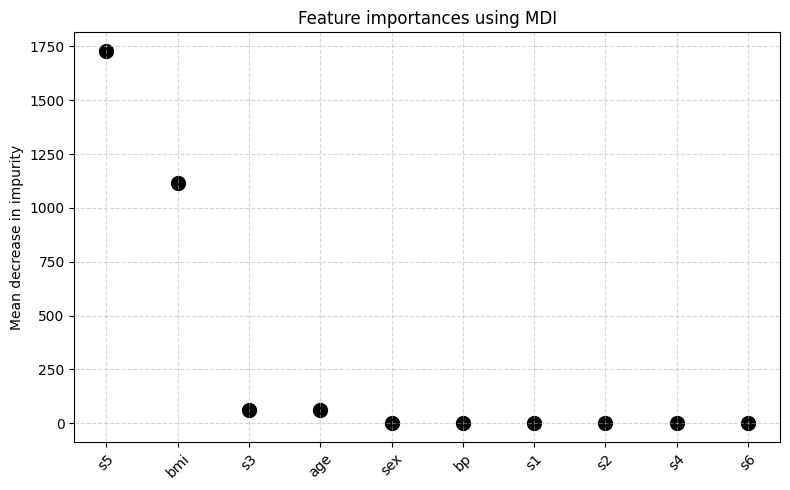

,Feature,MDI
8,s5,1728.808431
2,bmi,1115.869509
6,s3,62.555057
0,age,61.694426
1,sex,0.000000
3,bp,0.000000
4,s1,0.000000
5,s2,0.000000
7,s4,0.000000
9,s6,0.000000


In [57]:
# Initialize dict for MDI per feature
mdi_raw = {i: 0.0 for i in range(X.shape[1])}

# Compute node sample proportions
node_samples = tree_.n_node_samples / tree_.n_node_samples[0]  # proportion of data at each node

# Traverse all non-leaf nodes (i.e., internal splits)
for node_id in range(tree_.node_count):
    if tree_.feature[node_id] >= 0:  # -2 for leaves
        feature = tree_.feature[node_id]
        N = tree_.n_node_samples[node_id]
        N_left = tree_.n_node_samples[tree_.children_left[node_id]]
        N_right = tree_.n_node_samples[tree_.children_right[node_id]]

        # Variances
        impurity_parent = tree_.impurity[node_id]
        impurity_left = tree_.impurity[tree_.children_left[node_id]]
        impurity_right = tree_.impurity[tree_.children_right[node_id]]

        # Weighted impurity decrease
        delta = impurity_parent \
              - (N_left / N) * impurity_left \
              - (N_right / N) * impurity_right

        # Weight by proportion of data at this node
        mdi_raw[feature] += node_samples[node_id] * delta

# Convert to DataFrame and normalize
mdi_df = pd.DataFrame.from_dict(mdi_raw, orient='index', columns=['MDI']).reset_index()
mdi_df.columns = ['Feature Index', 'MDI']
mdi_df['Feature'] = mdi_df['Feature Index'].map(lambda i: X.columns[i])  # <- FIXED HERE
mdi_df = mdi_df.sort_values('MDI', ascending=False)


plot_mdi(mdi_df)
mdi_df[['Feature', 'MDI']]


## MDI from Scratch
We now compute the Mean Decrease in Impurity (MDI) **manually** using the internal structure of a trained decision tree.

At each internal node, we:
- Calculate the impurity decrease from a split (variance reduction),
- Weight it by the proportion of training data reaching that node,
- Accumulate these values for each splitting feature.

This demonstrates the true inner workings of MDI, consistent with the formulas discussed in the lecture.

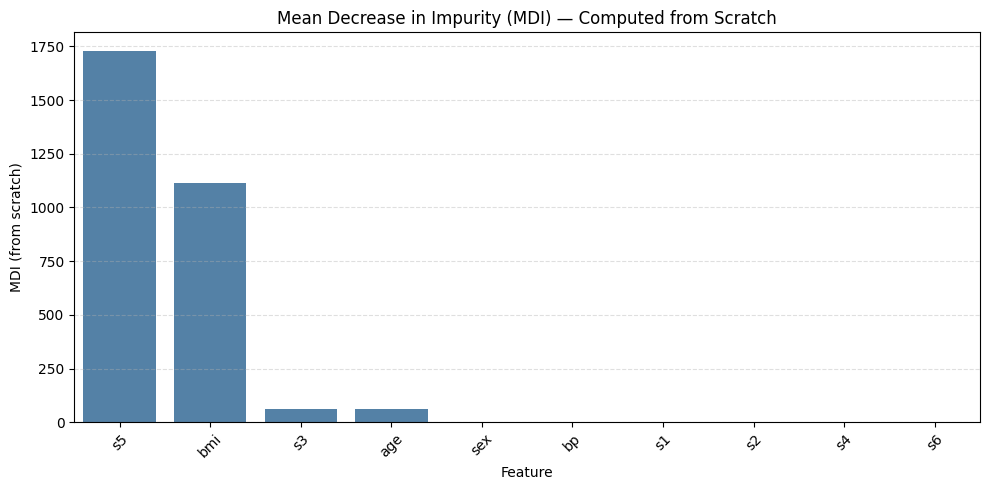

In [58]:
plt.figure(figsize=(10, 5))
sns.barplot(data=mdi_df, x="Feature", y="MDI", color="steelblue")
plt.title("Mean Decrease in Impurity (MDI) — Computed from Scratch")
plt.xticks(rotation=45)
plt.ylabel("MDI (from scratch)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("mdi_from_scratch.pdf")
plt.show()



In [59]:
# MDI vs MDA Comparison
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Compute MDI
mdi = rf.feature_importances_
mdi_df = pd.DataFrame({'Feature': X.columns, 'MDI': mdi})

# Compute MDA (permutation importance)
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
mda_df = pd.DataFrame({'Feature': X.columns, 'MDA': perm.importances_mean})

# Combine
compare_df = pd.merge(mdi_df, mda_df, on='Feature').sort_values('MDI', ascending=False)
compare_df

,Feature,MDI,MDA
2,bmi,0.355469,0.224080
8,s5,0.230957,0.251169
3,bp,0.088408,0.024449
9,s6,0.071329,0.021204
0,age,0.058642,0.007844
5,s2,0.057227,-0.003065
4,s1,0.052784,-0.010535
6,s3,0.051339,-0.010631
7,s4,0.024213,-0.001646
1,sex,0.009633,0.020924


## MDA

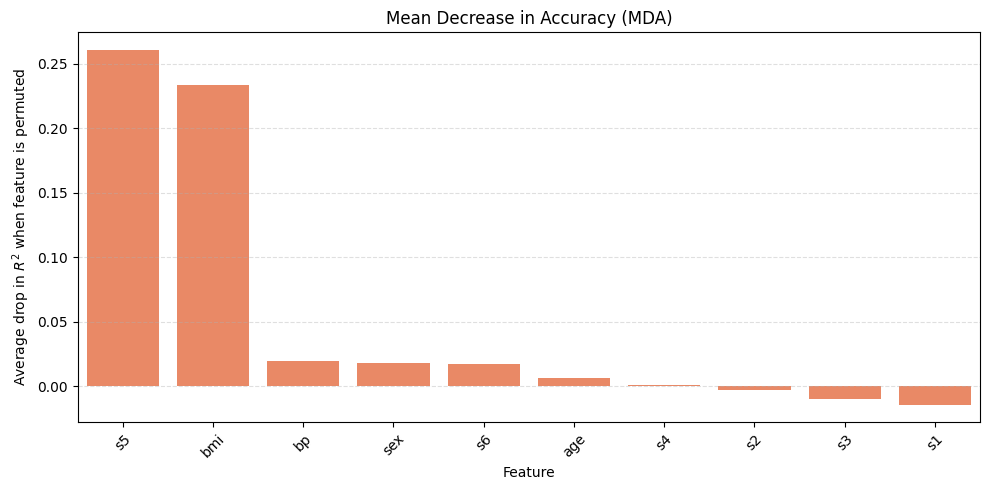

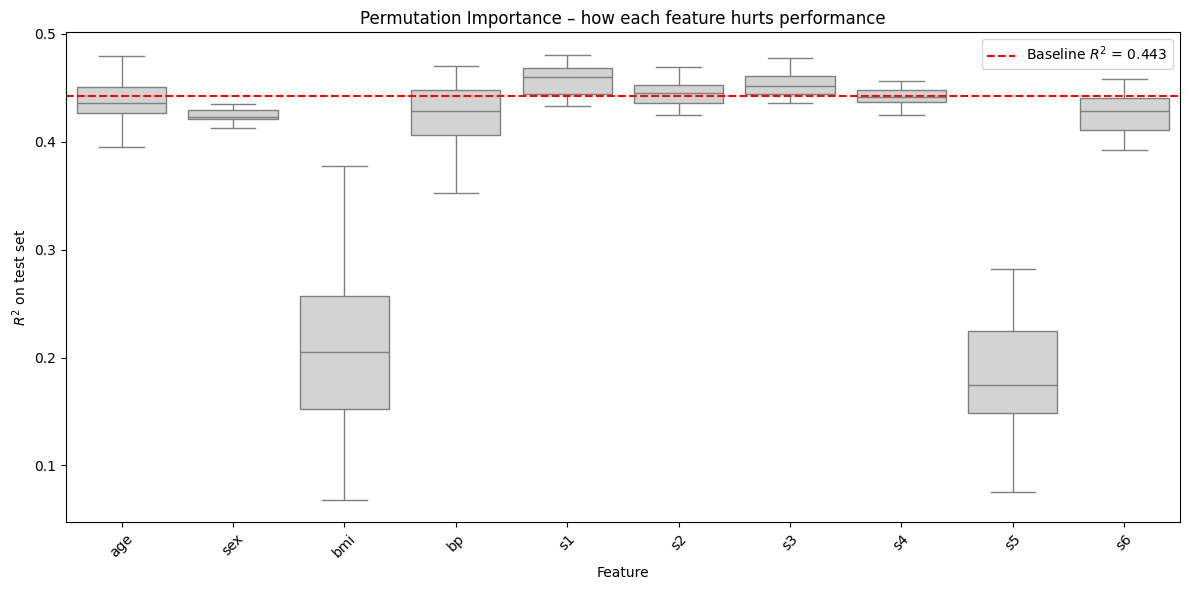

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------
# 1. Prepare data & model
# ------------------------------------------------------------------
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# ------------------------------------------------------------------
# 2. Baseline performance and permutation importance
# ------------------------------------------------------------------
baseline_r2 = r2_score(y_test, rf.predict(X_test))

perm = permutation_importance(
    rf, X_test, y_test, n_repeats=30, random_state=42
)

# DataFrame of mean decrease (MDA)
mda_df = pd.DataFrame({
    "Feature": X.columns,
    "MDA": perm.importances_mean
}).sort_values("MDA", ascending=False)

# ------------------------------------------------------------------
# 3. Plot ❶ – bar chart of mean decrease in accuracy
# ------------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(
    data=mda_df,
    x="Feature", y="MDA",
    color="coral"
)
plt.title("Mean Decrease in Accuracy (MDA)")
plt.ylabel("Average drop in $R^{2}$ when feature is permuted")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("mda_bar.pdf")   # ← saved as PDF
plt.show()

# ------------------------------------------------------------------
# 4. Plot ❷ – distribution of $R^{2}$ after each permutation
# ------------------------------------------------------------------
# Build long DataFrame: each repeat → one row
drop_dist = (
    pd.DataFrame(perm.importances, index=X.columns)
      .T.melt(var_name="Feature", value_name="Delta_R2")
)
drop_dist["Permuted_R2"] = baseline_r2 - drop_dist["Delta_R2"]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=drop_dist, x="Feature", y="Permuted_R2",
    color="lightgrey"
)
# Optional: swap to violinplot for a smoother look
# sns.violinplot(data=drop_dist, x="Feature", y="Permuted_R2", inner="quartile", color="lightgrey")

plt.axhline(
    baseline_r2, ls="--", color="red",
    label=f"Baseline $R^{2}$ = {baseline_r2:.3f}"
)
plt.title("Permutation Importance – how each feature hurts performance")
plt.ylabel("$R^{2}$ on test set")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("mda_visualization.pdf")   # ← saved as PDF
plt.show()


## Comparison MDI vs. MDA

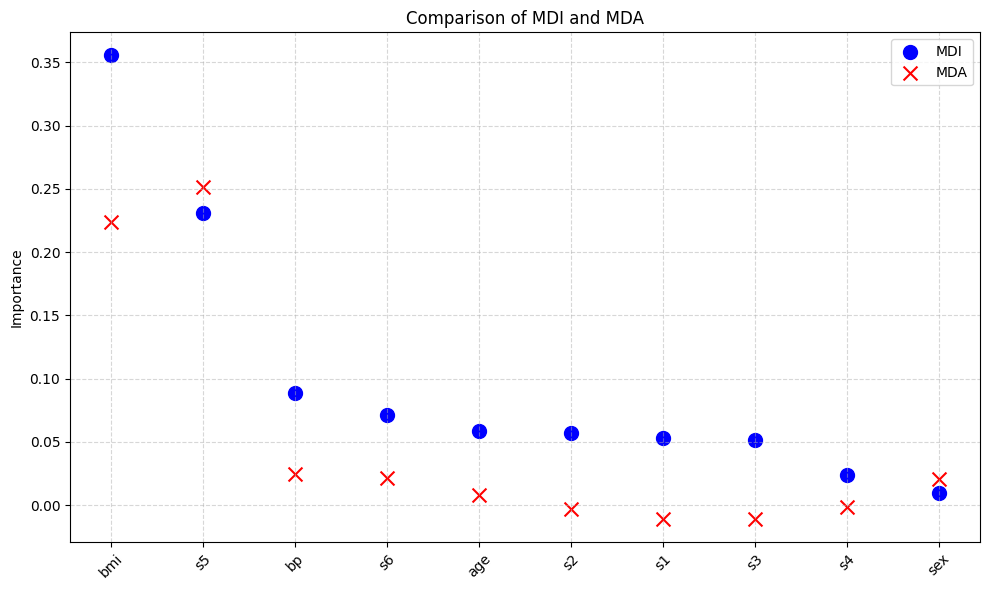

In [61]:
# Dot plot: MDI vs MDA
plt.figure(figsize=(10, 6))
plt.scatter(compare_df['Feature'], compare_df['MDI'], label='MDI', color='blue', s=100)
plt.scatter(compare_df['Feature'], compare_df['MDA'], label='MDA', color='red', marker='x', s=100)
plt.xticks(rotation=45)
plt.ylabel('Importance')
plt.title('Comparison of MDI and MDA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()